# 선형회귀

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 단순선형회귀 모델 만들기

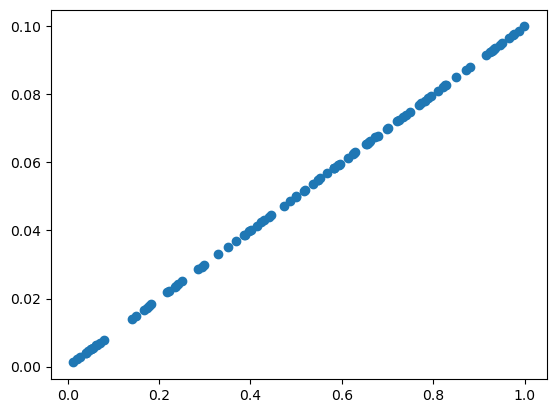

In [4]:
X = np.random.rand(100)
y = 0.2 * X * 0.5   # ax + b

plt.scatter(X,y)

In [5]:
def plt_prediction(pred, y):
    plt.figure(figsize=(8,6))
    plt.scatter(X, y, color='blue', label='Actual')   # 실제값
    plt.scatter(X, pred, color='orange', label='Prediction')   # 예측값
    plt.legend()
    plt.show()

# 경사하강법 y = wX+b, w 결정

In [6]:
w = np.random.uniform(-1, 1)   #임의의 값
b = np.random.uniform(-1, 1)   #임의의 값

learning_rate = 0.5   #임의의 값

Epoch 0, w : -0.2598, Error : 0.3353


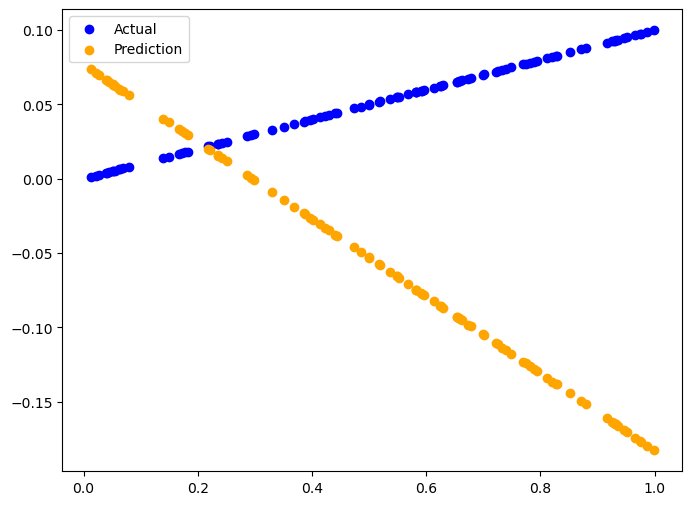

Epoch 10, w : -0.1193, Error : 0.0559


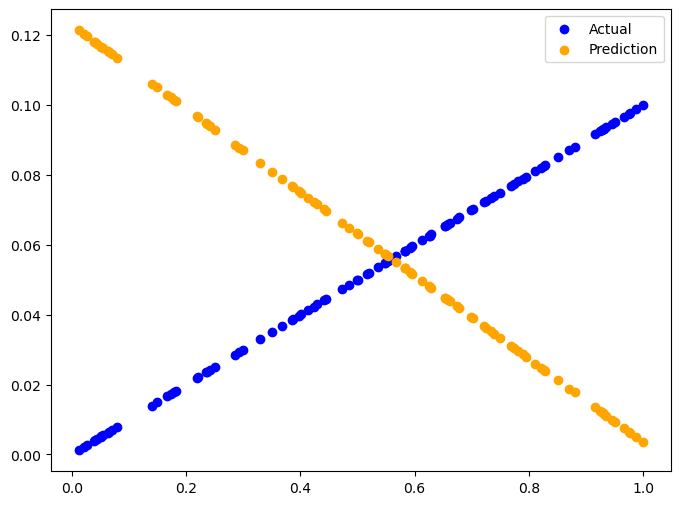

Epoch 20, w : -0.0569, Error : 0.0399


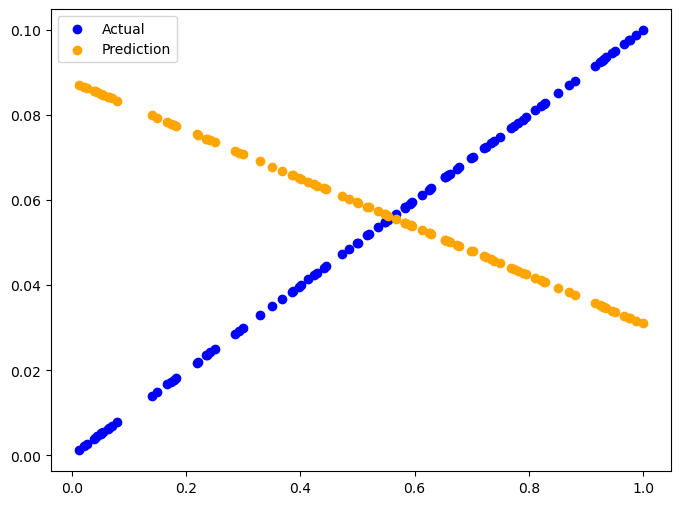

Epoch 30, w : -0.0122, Error : 0.0286


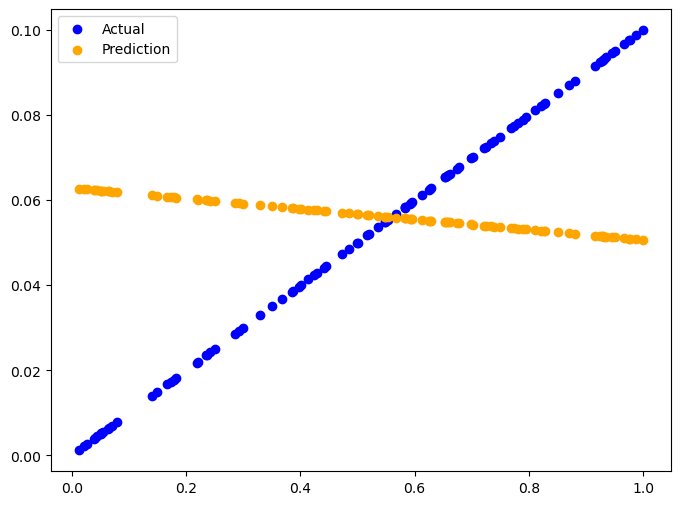

Epoch 40, w : 0.0197, Error : 0.0204


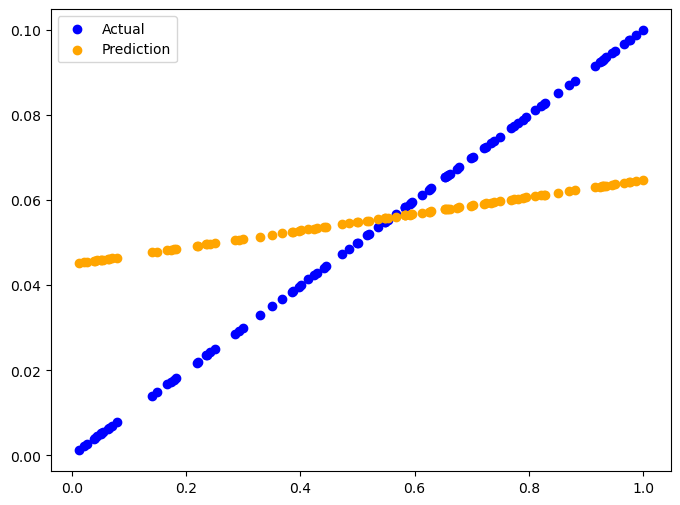

Epoch 50, w : 0.0426, Error : 0.0146


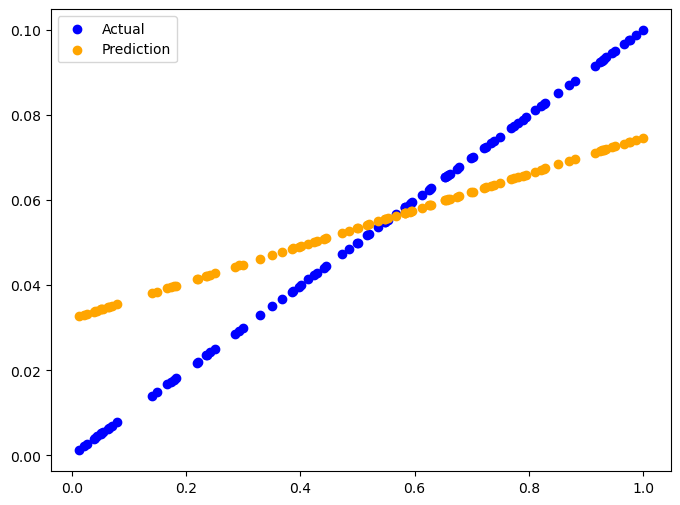

Epoch 60, w : 0.0589, Error : 0.0105


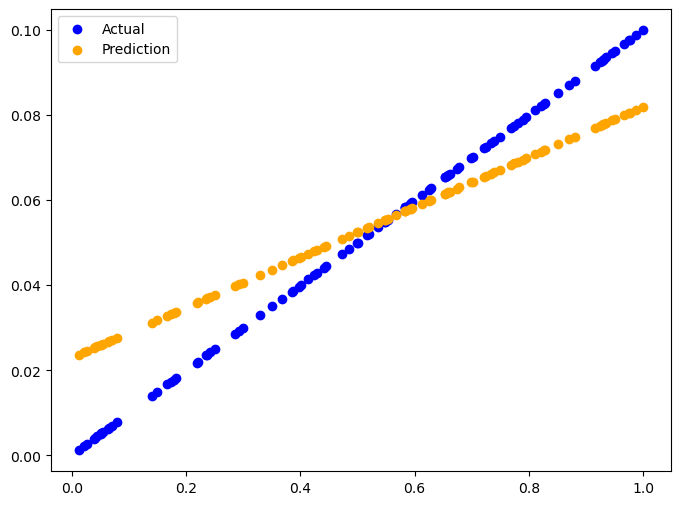

Epoch 70, w : 0.0706, Error : 0.0075


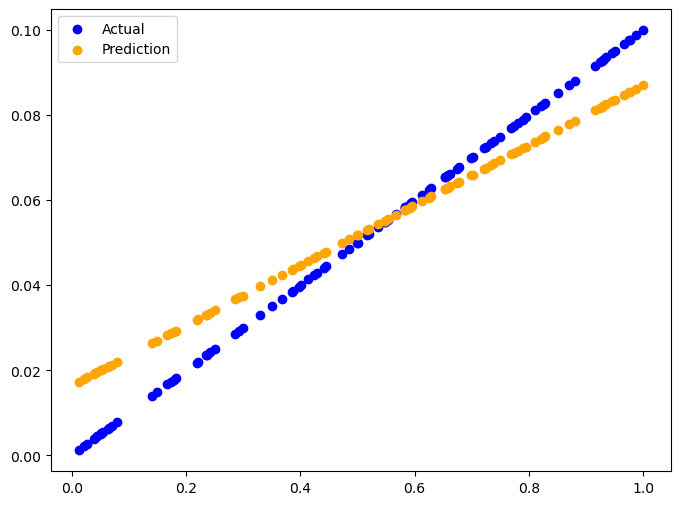

Epoch 80, w : 0.0790, Error : 0.0053


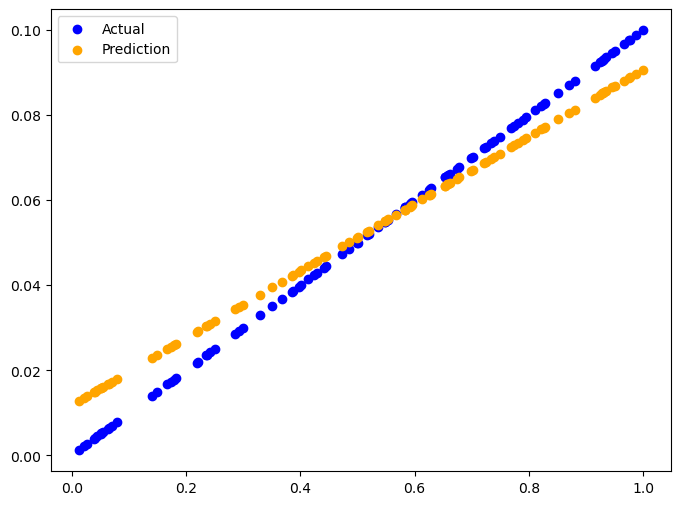

Epoch 90, w : 0.0850, Error : 0.0038


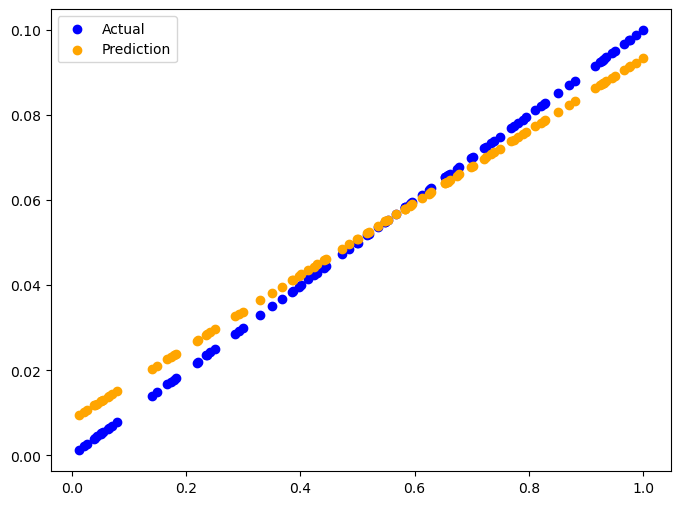

In [7]:
for epoch in range(100):
    y_pred = w * X + b
    error = np.abs(y_pred - y).mean()   # 손실함수
    if error < 0.001:
        break
    w_descent = learning_rate * ((y_pred - y) * X).mean()
    b_descent = learning_rate * ((y_pred - y).mean())
    w = w - w_descent
    b = b - b_descent
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, w : {w:.4f}, Error : {error:.4f}')
        y_pred = w * X + b
        plt_prediction(y_pred, y)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [9]:
bostonDF = pd.read_csv('./data/boston.csv')
bostonDF.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'target'],
      dtype='object')

In [10]:
bostonDF.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,target
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [11]:
X = bostonDF.drop('target', axis=1).values
y = bostonDF['target'].values
bostonDF.shape

(506, 14)

# 모델 만들기 (보스턴 집값)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=156)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
y_pred[:3]

array([23.15424087, 19.65590246, 36.42005168])

In [13]:
# 평가
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rmse, mse

(np.float64(4.158956107955705), np.float64(17.296915907902065))

In [14]:
# 결정계수
r2_score(y_test, y_pred)

np.float64(0.7572263323138934)

In [15]:
# 회귀식
# w0, w1
lr.intercept_, lr.coef_

(np.float64(40.99559517216439),
 array([-1.12979614e-01,  6.55124002e-02,  3.44366694e-02,  3.04589777e+00,
        -1.97958320e+01,  3.35496880e+00,  5.93713290e-03, -1.74185354e+00,
         3.55884364e-01, -1.42954516e-02, -9.20180066e-01,  1.03966156e-02,
        -5.66182106e-01]))

y = w0 + w1*X1 + w2*X2 + ... + w13*X13 이므로 w가 13개 나온다

In [16]:
np.round(lr.intercept_, 1), np.round(lr.coef_, 1)

(np.float64(41.0),
 array([ -0.1,   0.1,   0. ,   3. , -19.8,   3.4,   0. ,  -1.7,   0.4,
         -0. ,  -0.9,   0. ,  -0.6]))

In [17]:
pd.Series(data=np.round(lr.coef_, 1), index=bostonDF.drop('target', axis=1).columns).sort_values(ascending=False)

RM          3.4
CHAS        3.0
RAD         0.4
ZN          0.1
INDUS       0.0
B           0.0
TAX        -0.0
AGE         0.0
CRIM       -0.1
LSTAT      -0.6
PTRATIO    -0.9
DIS        -1.7
NOX       -19.8
dtype: float64

In [18]:
from sklearn.model_selection import cross_val_score
neg_mse_score = cross_val_score(lr, X, y, scoring='neg_mean_squared_error', cv=5)
neg_mse_score

array([-12.46030057, -26.04862111, -33.07413798, -80.76237112,
       -33.31360656])

In [19]:
# MSE, RMSE
RMSE = np.sqrt(neg_mse_score * -1)
np.mean(RMSE), RMSE

(np.float64(5.828658946215813),
 array([3.52991509, 5.10378498, 5.75101191, 8.9867887 , 5.77179405]))

In [20]:
# R2
r2_scores = cross_val_score(lr, X, y, scoring='r2', cv=5)
r2_scores, np.mean(r2_scores)

(array([ 0.63919994,  0.71386698,  0.58702344,  0.07923081, -0.25294154]),
 np.float64(0.3532759243958839))

오차는 커지고(4.15 -> 5.85), 결정계수는 작아진(0.75 -> 0.35) 결과

# 다항회귀모델
y = w0 + w1 * x1 + w2 * x2 + x3 * x1^2 + w4 * x2^2

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=156)
model_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('linear', LinearRegression())]
)
model_poly.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('linear', LinearRegression())])

In [23]:
pred_poly = model_poly.predict(X_test)
mean_squared_error(y_test, pred_poly)

np.float64(15.555752307472005)

In [24]:
r2_score(y_test, pred_poly)

np.float64(0.7816647163338353)

#### 2차~5차 다항회귀 시뮬레이션 (LineareRegressor)

In [61]:
results = []
best_r2=-np.inf
best_model = None
best_pred = None

for degree in range(1,5):
    model_poly = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('linear', LinearRegression())]
    )
    model_poly.fit(X_train, y_train)
    pred_poly = model_poly.predict(X_test)
    mse = mean_squared_error(y_test, pred_poly)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred_poly)
    results.append({'degree':degree, 'MSE':mse, 'RMSE':rmse, 'R2':r2})
    if r2 > best_r2:
        best_r2 = r2
        best_model = model_poly
        best_pred = pred_poly
    
pd.DataFrame(results)

,degree,MSE,RMSE,R2
0,1,17.296916,4.158956,0.757226
1,2,15.555752,3.944078,0.781665
2,3,79625.592348,282.180071,-1116.597912
3,4,170599.948638,413.037466,-2393.483240


+ 결과를보니 R2스코어가 3차에서 갑자기 마이너스로 값이 뚝 떨어져서 이 모델은 3차까지 갈 필요가 없다

#### 2차~5차 다항회귀 시뮬레이션 (RandomForest)

In [26]:
from sklearn.ensemble import RandomForestRegressor

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=156)
model_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('RandomForest', RandomForestRegressor())]
)
model_poly.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('RandomForest', RandomForestRegressor())])

In [33]:
pred_poly = model_poly.predict(X_test)
mean_squared_error(y_test, pred_poly)

np.float64(7.8078321973684215)

In [34]:
r2_score(y_test, pred_poly)

np.float64(0.8904119052595478)

In [63]:
results = []
best_r2=-np.inf
best_model = None
best_pred = None

for degree in range(1,6):
    model_poly = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('RandomForest', RandomForestRegressor(max_depth=5))]
    )
    model_poly.fit(X_train, y_train)
    pred_poly = model_poly.predict(X_test)
    mse = mean_squared_error(y_test, pred_poly)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred_poly)
    results.append({'degree':degree, 'MSE':mse, 'RMSE':rmse, 'R2':r2})
    if r2 > best_r2:
        best_r2 = r2
        best_model = model_poly
        best_pred = pred_poly
    
pd.DataFrame(results)

,degree,MSE,RMSE,R2
0,1,8.874005,2.978927,0.875447
1,2,9.189854,3.031477,0.871014
2,3,7.909528,2.812388,0.888985
3,4,8.495991,2.914788,0.880753
4,5,8.441699,2.905460,0.881515


+ 결과를보니 R2스코어가 3차에서 가장 좋게 나타난다

# 규제 회귀 모델

## Ridge

In [36]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

In [37]:
ridge = Ridge(alpha=1)   # 규제 강도
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

mse = mean_squared_error(y_test, pred_ridge)
r2 = r2_score(y_test, pred_ridge)
mse, r2

(np.float64(17.206833316177068), np.float64(0.7584907011357223))

+ aplha가 1일때 : 17.2 , 0.75

In [49]:
from sklearn.linear_model import RidgeCV, LassoCV
alphas = [0.001, 0.01,0.1, 1, 10, 100]
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)
ridge_preds = ridge_cv.predict(X_test)
ridge_mse = mean_squared_error(y_test, ridge_preds)
ridge_r2 = r2_score(y_test, ridge_preds)

print(f'ridge cv mse : {ridge_mse}, r2 : {ridge_r2}')

ridge cv mse : 17.29626010177991, r2 : 0.7572355369870509


In [50]:
ridge_cv.alpha_   # 최적의 알파값

np.float64(0.001)

## Lasso

In [ ]:
lasso = Lasso(alpha=1)   # 규제 강도
lasso.fit(X_train, y_train)
pred_lasso = lasso.predict(X_test)

mse = mean_squared_error(y_test, pred_lasso)
r2 = r2_score(y_test, pred_lasso)
mse, r2

(np.float64(22.137098759778443), np.float64(0.6892911611262599))

+ aplha가 1일때 : 22.1 , 0.69

In [52]:
from sklearn.linear_model import RidgeCV, LassoCV
alphas = [0.001, 0.01,0.1, 1, 10, 100]
lasso_cv = LassoCV(alphas=alphas, cv=5)
lasso_cv.fit(X_train, y_train)
lasso_preds = lasso_cv.predict(X_test)
lasso_mse = mean_squared_error(y_test, lasso_preds)
lasso_r2 = r2_score(y_test, lasso_preds)
print(f'lasso cv mse : {lasso_mse}, r2 : {lasso_r2}')

lasso cv mse : 17.283108558822182, r2 : 0.7574201276005788


In [53]:
lasso_cv.alpha_   # 최적의 알파값

np.float64(0.001)

In [54]:
lasso_cv.coef_

array([-1.12661593e-01,  6.56008407e-02,  3.30878096e-02,  3.02619848e+00,
       -1.94682482e+01,  3.35481221e+00,  5.71239360e-03, -1.73664047e+00,
        3.55109529e-01, -1.43215477e-02, -9.16008532e-01,  1.04167858e-02,
       -5.66946541e-01])

In [55]:
ridge_cv.coef_

array([-1.12963267e-01,  6.55168621e-02,  3.43623266e-02,  3.04560180e+00,
       -1.97781295e+01,  3.35506472e+00,  5.92317536e-03, -1.74158450e+00,
        3.55842743e-01, -1.42968313e-02, -9.19951783e-01,  1.03976785e-02,
       -5.66214215e-01])

lasso 모델에서 제거된 변수는 없다

# 엘라스틱넷

In [56]:
enet = ElasticNet(alpha=0.1, l1_ratio=0.5)
enet.fit(X_train, y_train)

ElasticNet(alpha=0.1)

In [58]:
pred_enet = enet.predict(X_test)
print("엘라스틱넷 회귀")
print(f"MSE : {mean_squared_error(y_test, pred_enet)}")
print(f"R2 : {r2_score(y_test, pred_enet)}")

엘라스틱넷 회귀
MSE : 18.11673827943616
R2 : 0.7457195824951279


# 모델 성능 비교

In [62]:
results = pd.DataFrame({
    '모델':['다항회귀', '릿지회귀', '라쏘회귀', '엘라스틱넷회귀'],
    'MSE' : [mean_squared_error(y_test, pred_poly),
             mean_squared_error(y_test, pred_ridge),
             mean_squared_error(y_test, pred_lasso),
             mean_squared_error(y_test, pred_enet)],
    'R2' : [r2_score(y_test, best_pred),
            r2_score(y_test, pred_ridge),
            r2_score(y_test, pred_lasso),
            r2_score(y_test, pred_enet)]
})
results

,모델,MSE,R2
0,다항회귀,170599.948638,0.781665
1,릿지회귀,17.206833,0.758491
2,라쏘회귀,22.137099,0.689291
3,엘라스틱넷회귀,18.116738,0.745720
